<a href="https://colab.research.google.com/github/vishnuiyer23ug-stack/computational-statistics-course-4/blob/main/Class_07_Regularization_and_Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import zipfile

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # This helps us chain the different steps of the process
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV # RidgeCV and LassoCV directly do the cross validation

!pip install ISLP
from ISLP import load_data

# We aren't using most of these packages here, but its nice to have for future reference

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=7b31aba5a0a02356f8a566b8e41ef45077be8224a0d44688f32a83742a002e0f
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


# Utility functions

In [2]:
# Compute RMSE (Root mean squared error)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Load data

In [3]:
df = load_data('Hitters')

Now lets take a look at the data

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


# Preprocessing
We need to find if there are missing values in the dataset and figure out a way to deal with them.

In [5]:
rows_with_na = df[df.isna().any(axis=1)]
print("\nRows containing NAs:")
rows_with_na
# We can see that the only missing values that we have are in the salary column which is what we are trying to predict.
# So, we will be dropping these values. There are 59 rows that are missing some data and these will be dropped


Rows containing NAs:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
15,183,39,3,20,15,11,3,201,42,3,20,16,11,A,W,118,0,0,NaN,A
18,407,104,6,57,43,65,12,5233,1478,100,643,658,653,A,W,912,88,9,NaN,A
22,22,10,1,4,2,1,6,84,26,2,9,9,3,A,W,812,84,11,NaN,A
30,313,84,9,42,30,39,17,6890,1833,224,1033,864,1087,A,W,127,221,7,NaN,A
32,517,141,27,70,87,52,9,3571,994,215,545,652,337,N,W,1378,102,8,NaN,N
36,161,36,0,19,10,17,4,1053,244,3,156,86,107,A,E,70,149,12,NaN,A
38,346,98,5,31,53,30,16,5913,1615,235,784,901,560,A,E,0,0,0,NaN,A
39,241,61,1,34,12,14,1,241,61,1,34,12,14,N,W,166,172,10,NaN,N
41,216,54,0,21,18,15,18,7318,1926,46,796,627,483,N,W,103,84,5,NaN,N


Let's drop the rows with NaN values and split the dataset into train and test.

In [6]:
df = df.dropna().reset_index(drop=True) # This drops all the NaNs. The reset index also makes sure the row numbers go from 0 to n
# without breaks after dropping some rows
target = "Salary"
X = df.drop(columns=[target]) # Everything except salary is in X
y = df[target] # Only salary is in Y
print(X.shape, y.shape)

# First split: train+val vs test (80% / 20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
) # 80% of the data goes into the training cum validation data, and 20% is set aside for the final test

# Second split: train vs validation (75% / 25% of remaining 80%)
# This gives: 60% train, 20% val, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=20
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

(263, 19) (263,)
Train size: 157
Validation size: 53
Test size: 53


Now we need to transform the categorical values into numerical values and also scale all the features so that they roughly lie within the same range. If some features are represented using large numbers while others are represented in small numbers, it can skew the error calculcations, similar to what happened when we did polynomial regression.

In [9]:
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist() # Here, we are selecting all the features that are numeric
# These will have to be scaled
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols), # Scales columns containing numerical data using (x-mu)/sigma so that the values have mean 0 and standard deviation 1
        ("cat", OneHotEncoder(drop="first"), categorical_cols) # Encodes categorical values using one hot encoding
    ]
) # Column transformer does something to every column. We have just defined the preprocess here, we will apply it to our data later.

print(numerical_cols)
print(categorical_cols)

['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors']
['League', 'Division', 'NewLeague']


In [10]:
# If you want to understand how the OneHotEncoder works, uncomment the below lines of code and try it out
X_1hot = [["East"], ["West"], ["Central"]]

enc = OneHotEncoder(drop="first", sparse_output=False) # Note- The encoder sorts the list of unique categories alphabetically before encoding
# So, the order becomes Central, East, West. Since we drop the first, we are dropping Central, and then creates new columns for each
# of the next columns.
encoded = enc.fit_transform(X_1hot) # So we have defined enc in the previous line, and then we are fitting the enc model here to X1_hot

print(encoded)

# The reason that we do not want to assign numbers 0,1,2 to the three categories is because this assumes ordering when there isnt any.
# The reason that we only make two columns when there are three categories is to avoid multicollinearity. Central will be linearly
# dependent on X1 and X2
# The output is read as follows:
# [1,0] is east
# [0,1] is west
# [0,0] is central

[[1. 0.]
 [0. 1.]
 [0. 0.]]


# Linear regression using OLS

In [23]:
# OLS Model
ols_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
]) # Pipeline executes whatever is inside it sequentially, so it does the preprocessing first, and then applies the linear regression model

# 2) Fit on training data. We're using the whole training data (with validation data) here because we want to compare this basic model
# with the ridge regression later on
ols_model.fit(X_train_val, y_train_val)

# 3) Predictions
y_train_pred = ols_model.predict(X_train_val)
y_test_pred  = ols_model.predict(X_test)


ols_test_rmse = rmse(y_test,y_test_pred)

print("OLS Performance:")
print("Train RMSE:", rmse(y_train_val, y_train_pred))
print("Test RMSE:", rmse(y_test, y_test_pred))

# We can see that our train and test rmse is super high so this is quite a bad model

OLS Performance:
Train RMSE: 306.3040695327462
Test RMSE: 309.4980873341895


Best lambda for ridge: 48.62601580065353
Best Validation RMSE for ridge: 347.5943722166363
Best lambda for lasso: 2.9836472402833403
Best Validation RMSE for lasso: 350.19440206990436


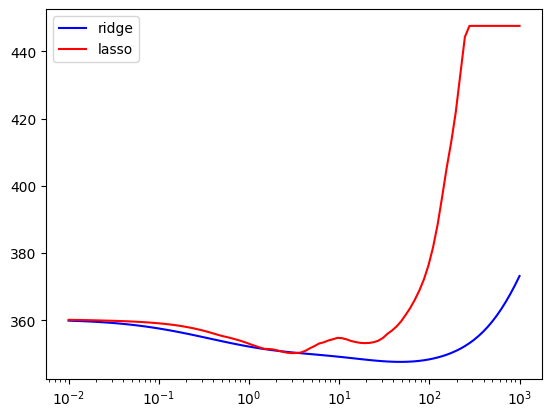

In [29]:
# Define lambdas grid
lambdas = np.logspace(-2, 3, 100) # It divides the range -2,3 logarithmically (default base 10). So here we have a range from 10^-2
# to 10^3. The reason that we want to partition logarithmically and not linearly is because we are dealing with a very large range
# and we have no idea which value of lambda is most suitable. Partitioning logarithmically initially gives us a good range of values.
# Once we have a better idea of the range of lambda which are suitable, we can divide the range again linearly

# 5-fold CV
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

ridge_val_rmse = np.full((num_folds, len(lambdas)), np.inf) # Here we are creating a 2d array with the right dimensionality. The number
# of rows is the number of folds, and the number of lamdas is the number of columns. We have filled each of the cells with infinity,
# because ideally as lambda increases, the rmse will go down. So, if we fill in the cells with zeroes, we may not be able to tell how
# the rmse is decreasing.
lasso_val_rmse = np.full((num_folds, len(lambdas)), np.inf)

for l_ind, l in enumerate(lambdas):
  fold = 0

  for train_idx, val_idx in kf.split(X_train_val): # So, the idx stands for index and it helps us split the data into training and
  # validation in each iteration. It changes which fold goes into validation in each iteration.

    X_train_fold = X_train_val.iloc[train_idx]
    y_train_fold = y_train_val.iloc[train_idx]
    X_val_fold   = X_train_val.iloc[val_idx]
    y_val_fold   = y_train_val.iloc[val_idx]

    # Pipeline: preprocessing + Ridge
    ridge_model = Pipeline([
            ("preprocess", preprocess),
            ("ridge", Ridge(alpha=l, max_iter=10000)) # Here alpha is the same as lambda. We have assigned alpha = l, and we are
            # iterating over the ls (this is a lowercase L by the way not a 1)
        ])

    ridge_model.fit(X_train_fold, y_train_fold)
    ridge_preds = ridge_model.predict(X_val_fold)

    ridge_val_rmse[fold, l_ind] = rmse(y_val_fold, ridge_preds)

    # Pipeline: preprocessing + Lasso
    lasso_model = Pipeline([
            ("preprocess", preprocess),
            ("lasso", Lasso(alpha=l, max_iter=10000))
        ])

    lasso_model.fit(X_train_fold, y_train_fold)
    lasso_preds = lasso_model.predict(X_val_fold)

    lasso_val_rmse[fold, l_ind] = rmse(y_val_fold, lasso_preds)

    fold += 1

ridge_mean_rmse = np.mean(ridge_val_rmse, axis=0) # Takes mean along the rows, i.e., the mean of the rmse that have gone into our array
lasso_mean_rmse = np.mean(lasso_val_rmse, axis = 0)
# print(ridge_mean_rmse)
# print(lasso_mean_rmse)

# Find best lambda
ridge_best_lambda = lambdas[np.argmin(ridge_mean_rmse)]
print("Best lambda for ridge:", ridge_best_lambda)
print("Best Validation RMSE for ridge:", min(ridge_mean_rmse))

lasso_best_lambda = lambdas[np.argmin(lasso_mean_rmse)]
print("Best lambda for lasso:", lasso_best_lambda)
print("Best Validation RMSE for lasso:", min(lasso_mean_rmse))


# Plot the lambdas vs mean_rmse for ridge and lasso
plt.figure()
plt.plot(lambdas, ridge_mean_rmse, c="b", label="ridge")
plt.plot(lambdas, lasso_mean_rmse, c="r", label="lasso")
plt.xscale('log')
plt.legend()

# Fit the final model
Now that we have the best lambda values, we can try to fit the whole train+val dataset using these values.

In [33]:
# Ridge
ridge_final_model = Pipeline([
    ("preprocess", preprocess),
    ("ridge", Ridge(alpha=ridge_best_lambda))
])

ridge_final_model.fit(X_train_val, y_train_val)

ridge_test_preds = ridge_final_model.predict(X_test)

# Lasso
lasso_final_model = Pipeline([
    ("preprocess", preprocess),
    ("lasso", Lasso(alpha= lasso_best_lambda))
])

lasso_final_model.fit(X_train_val, y_train_val)

lasso_test_preds = lasso_final_model.predict(X_test)



print("Test RMSE for OLS:", ols_test_rmse)
print("Test RMSE for Ridge Regression with cross validation:", rmse(y_test, ridge_test_preds))
print("Test RMSE for Lasso Regression with cross validation:", rmse(y_test, lasso_test_preds))

# Ridge and Lasso Regression do slightly better than the OLS, but not really by much in this case. Compared to the number of datapoints,
# our number of features is still pretty low, so we are still in the "safe zone". If this pattern wasn't there, there would probably
# be a much larger difference between the methods. Lasso does slightly better than Ridge in this case.

Test RMSE for OLS: 309.4980873341895
Test RMSE for Ridge Regression with cross validation: 296.1859621013697
Test RMSE for Lasso Regression with cross validation: 289.88176363442216


In [38]:
# Try getting the coefficients of the each of the models. For ridge and lasso, use the best model and find those coefficients

# Ridge Coefficients
ridge_final_model.named_steps['ridge'].coef_



array([ -3.92882891,  60.05381134, -23.4769597 ,  23.31110695,
        15.06957457,  45.48753057, -12.81901263,  25.01218468,
        55.77812909,  49.12915697,  59.4742746 ,  59.86349729,
       -22.11420112,  55.80082818,  19.68674669, -13.79462903,
        25.70859334, -73.77743109,   3.2853078 ])

In [39]:
# Lasso Model Coefficients
lasso_final_model.named_steps['lasso'].coef_

array([-194.1253915 ,  219.0356881 ,  -14.83500394,   -4.51330336,
         -0.        ,  108.14921573,  -37.22677805,   -0.        ,
          0.        ,   48.59653568,  280.67778617,  125.50694219,
       -213.34854576,   67.67823153,   34.08429756,  -10.71542957,
         31.14313129, -132.28042934,   -0.        ])

In [42]:
# Ols coefficients

ols_model.named_steps['model'].coef_

array([-290.2935441 ,  396.7306644 ,   46.66233223, -121.94120927,
        -65.73165203,  158.6552347 ,    8.41256436, -407.59520951,
        -98.04544745,  -62.29795582,  727.64237834,  354.32590139,
       -340.03452427,   67.22428449,   57.38251471,  -15.54323392,
        113.01458494, -136.34133724,  -80.71225002])